  <tr>
        <td>
            <div align="left">
                <font size=25px>
                    <b> Predicting whether the employee gets promoted or not
                    </b>
                </font>
            </div>
        </td>
    </tr>

# Problem Statement :
Analyze the dataset to explore the machine learning algorithms and different models to predict the promotion.

# Data Definition:
## Variable Description:

### Column	Description 
    1. employee_id	Unique ID for employee
    2. department	Department of employee
    3. region	Region of employment (unordered)
    4. education	Education Level
    5. gender	Gender of Employee
    6. recruitment_channel	Channel of recruitment for employee
    7. no_of_trainings	no of other trainings completed in previous year on soft skills, technical skills etc.
    8. age	Age of Employee
    9. previous_year_rating	Employee Rating for the previous year
    10. length_of_service	Length of service in years
    11. KPIs_met >80%	if Percent of KPIs(Key performance Indicators) >80% then 1 else 0
    12. awards_won?	if awards won during previous year then 1 else 0
    13. avg_training_score	Average score in current training evaluations
    
    
    14. is_promoted	(Target) Recommended for promotion


## Importing Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

## Loading the Data

In [3]:
train_hr=pd.read_csv(r'C:\Users\HELLO\Downloads\train_hr.csv',index_col=0)
test_hr=pd.read_csv(r'C:\Users\HELLO\Downloads\test_hr.csv')
train_hr.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
employee_id,,,,,,,,,,,,,
65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
print(train_hr.shape)
print(test_hr.shape)

(54808, 13)
(23490, 13)


## Understanding the Data

In [5]:
train_hr.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 54808 entries, 65438 to 51526
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   department            54808 non-null  object 
 1   region                54808 non-null  object 
 2   education             52399 non-null  object 
 3   gender                54808 non-null  object 
 4   recruitment_channel   54808 non-null  object 
 5   no_of_trainings       54808 non-null  int64  
 6   age                   54808 non-null  int64  
 7   previous_year_rating  50684 non-null  float64
 8   length_of_service     54808 non-null  int64  
 9   KPIs_met >80%         54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.9+ MB


In [6]:
train_hr.dtypes

department               object
region                   object
education                object
gender                   object
recruitment_channel      object
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPIs_met >80%             int64
awards_won?               int64
avg_training_score        int64
is_promoted               int64
dtype: object

## Statistical Summary

In [7]:
train_hr.describe()

,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [8]:
train_hr.columns

Index(['department', 'region', 'education', 'gender', 'recruitment_channel',
       'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPIs_met >80%', 'awards_won?', 'avg_training_score', 'is_promoted'],
      dtype='object')

## Visualization

In [9]:
train_hr['is_promoted'].unique()

array([0, 1], dtype=int64)

Number of employees promoted :  50140
Number of employees not promoted :  4668


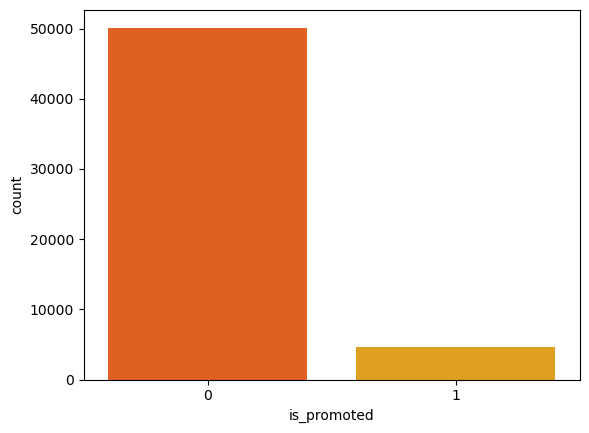

In [10]:
sns.countplot(x=train_hr['is_promoted'],data=train_hr,palette="autumn")
S, N = train_hr['is_promoted'].value_counts()
print('Number of employees promoted : ',S)
print('Number of employees not promoted : ',N)

* The data is imbalanced so there is need to apply smote.

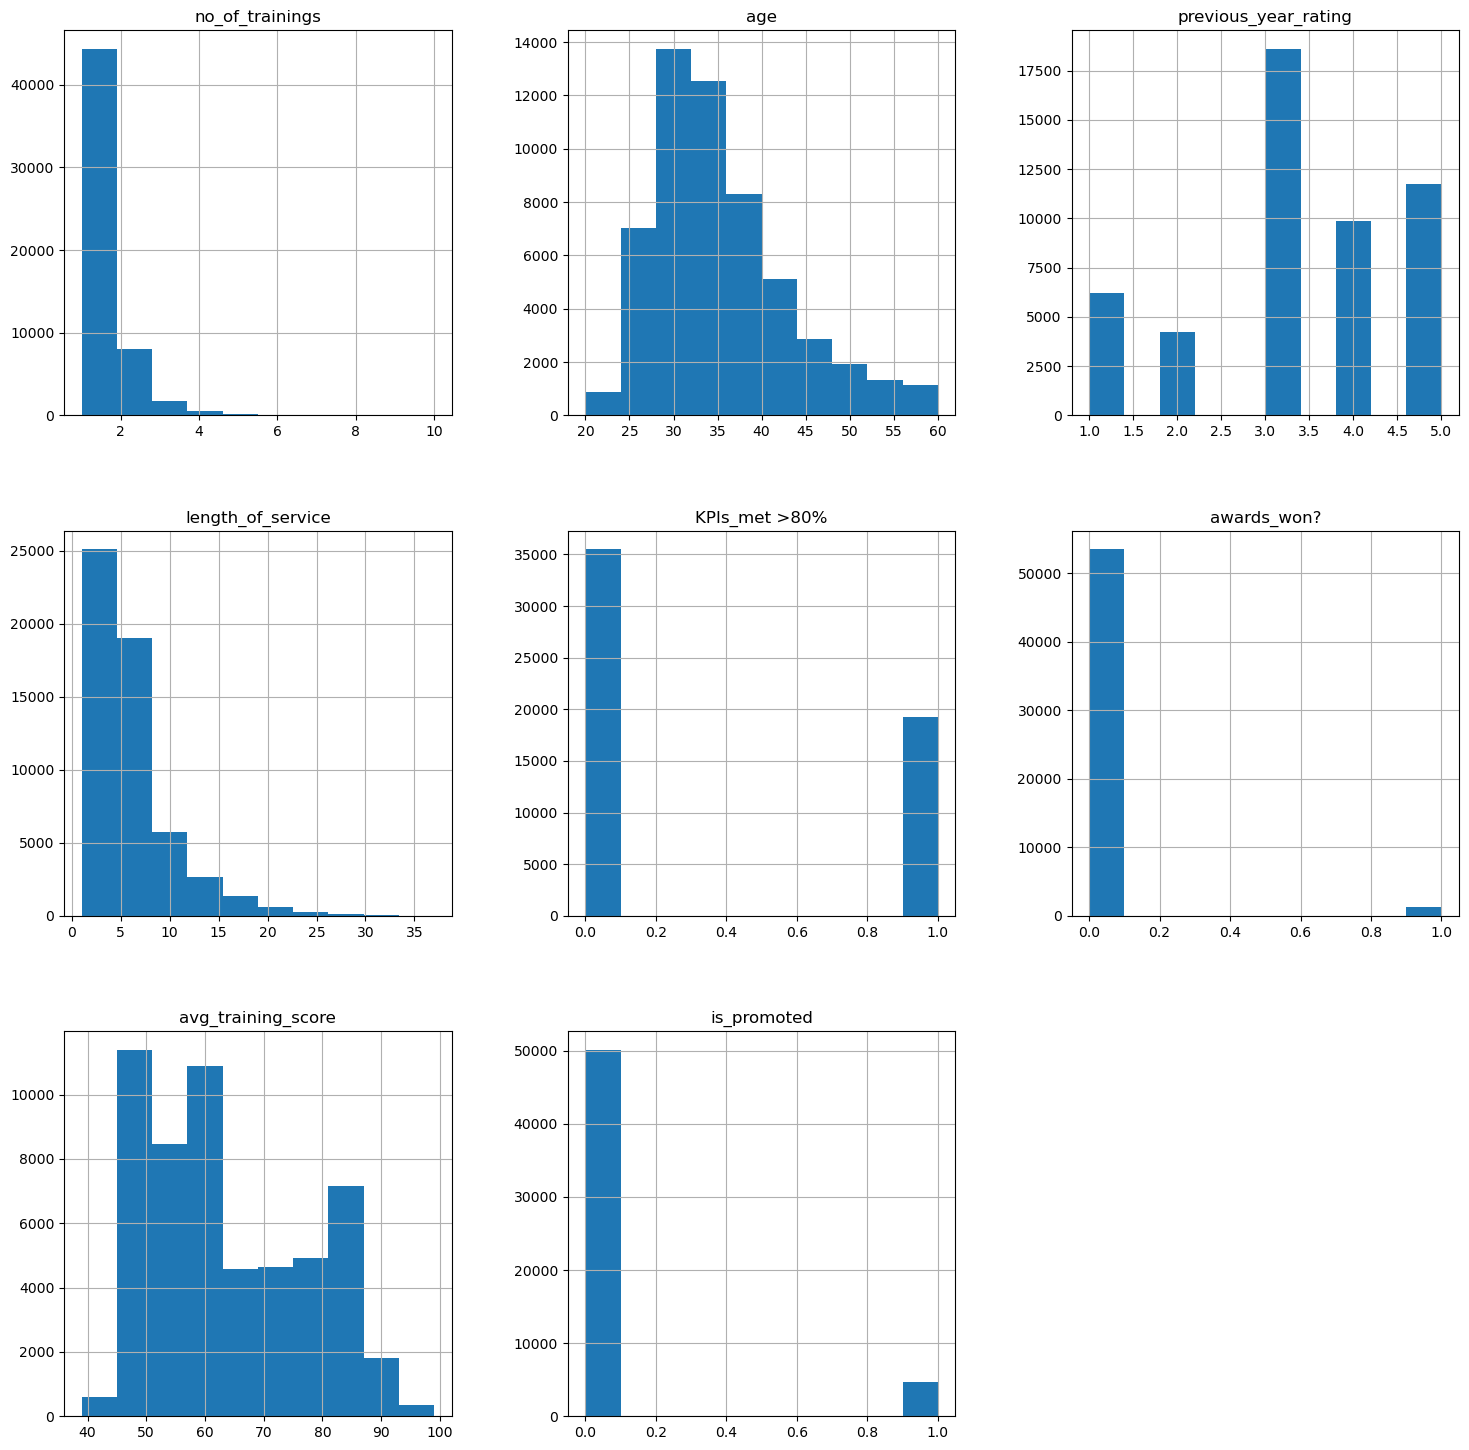

In [11]:
fig = train_hr.hist(figsize = (18,18))

* From the histograms we can understand the distribution of the data.

## Handling duplicated and missing values

In [12]:
train_hr.duplicated().sum()

118

In [13]:
train_hr.drop_duplicates(inplace=True)

In [14]:
train_hr.isnull().sum()

department                 0
region                     0
education               2398
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4062
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [15]:
train_hr.dropna(inplace=True)

In [16]:
colname=[]
for x in train_hr.columns:
    if train_hr[x].dtype=='object':
        colname.append(x)
print(colname)

['department', 'region', 'education', 'gender', 'recruitment_channel']


In [17]:
train_df_num = train_hr.copy()

In [18]:
train_df_num.drop(['is_promoted'],axis=1,inplace=True)

## Correlation

In [19]:
corr = train_df_num.corr()
print(corr)


                      no_of_trainings       age  previous_year_rating  \
no_of_trainings              1.000000 -0.083693             -0.064272   
age                         -0.083693  1.000000              0.004946   
previous_year_rating        -0.064272  0.004946              1.000000   
length_of_service           -0.055460  0.620316             -0.001329   
KPIs_met >80%               -0.046798 -0.033927              0.352296   
awards_won?                 -0.008579 -0.010395              0.027910   
avg_training_score           0.041909 -0.066263              0.069972   

                      length_of_service  KPIs_met >80%  awards_won?  \
no_of_trainings               -0.055460      -0.046798    -0.008579   
age                            0.620316      -0.033927    -0.010395   
previous_year_rating          -0.001329       0.352296     0.027910   
length_of_service              1.000000      -0.089058    -0.043798   
KPIs_met >80%                 -0.089058       1.000000     0

<Axes: >

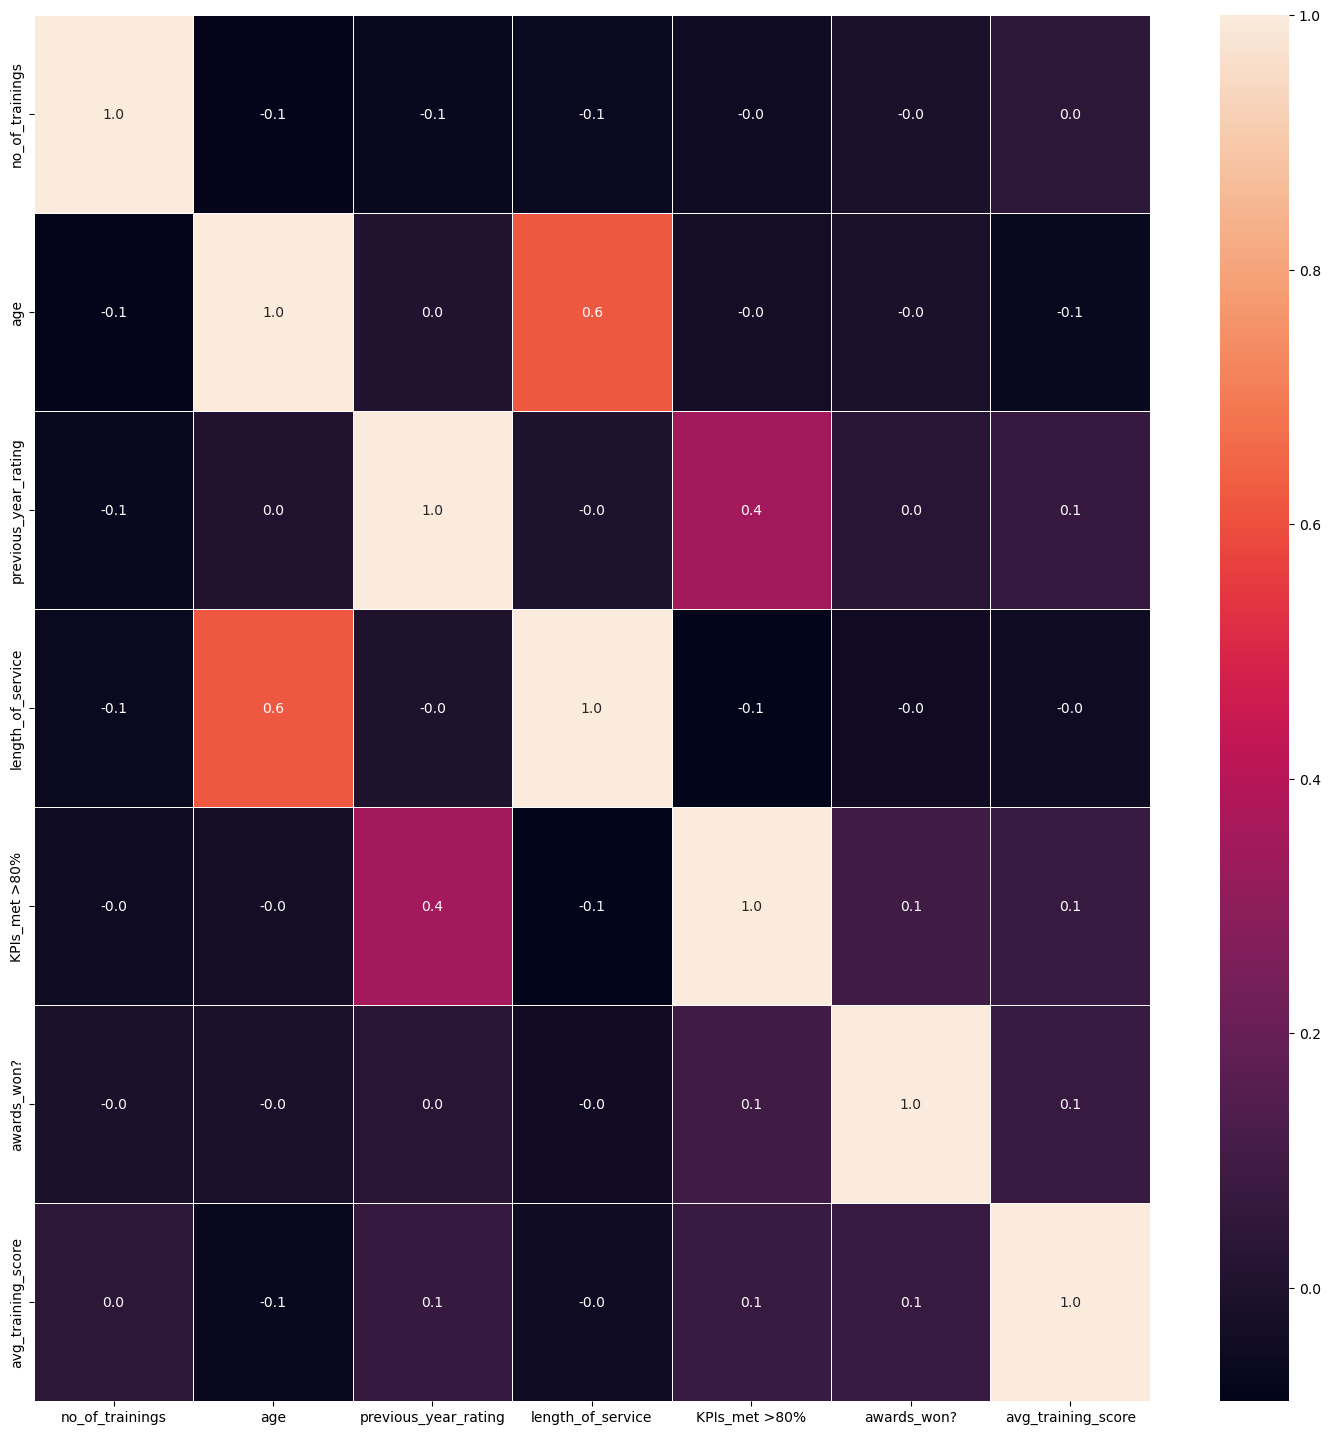

In [20]:
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(train_df_num.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)

In [21]:
train_hr.columns

Index(['department', 'region', 'education', 'gender', 'recruitment_channel',
       'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
       'KPIs_met >80%', 'awards_won?', 'avg_training_score', 'is_promoted'],
      dtype='object')

## Converting Categorical Variables into Numerical

In [22]:
from sklearn.preprocessing import LabelEncoder
 
le=LabelEncoder() #create object
 
for x in colname:
    train_hr[x]=le.fit_transform(train_hr[x])

In [23]:
X =train_hr.iloc[:, :-1]
Y =train_hr.iloc[:,-1]
Y=Y.astype(int)

In [24]:
train_hr

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
employee_id,,,,,,,,,,,,,
65438,7,31,2,0,2,1,35,5.0,8,1,0,49,0
65141,4,14,0,1,0,1,30,5.0,4,0,0,60,0
7513,7,10,0,1,2,1,34,3.0,7,0,0,50,0
2542,7,15,0,1,0,2,39,1.0,10,0,0,50,0
48945,8,18,0,1,0,1,45,3.0,2,0,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6915,7,5,0,1,0,2,31,1.0,2,0,0,49,0
3030,8,5,0,1,2,1,48,3.0,17,0,0,78,0
74592,4,19,2,0,0,1,37,2.0,6,0,0,56,0


In [25]:
X.dtypes

department                int32
region                    int32
education                 int32
gender                    int32
recruitment_channel       int32
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPIs_met >80%             int64
awards_won?               int64
avg_training_score        int64
dtype: object

## Variance Inflation Factor

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
vif_df = pd.DataFrame()
vif_df["features"] = X.columns
vif_df["VIF Factor"] = [vif(X.values, i) for i in range(X.shape[1])]
vif_df = vif_df.round(2)

print(vif_df)

                features  VIF Factor
0             department        4.74
1                 region        3.86
2              education        1.60
3                 gender        3.24
4    recruitment_channel        1.77
5        no_of_trainings        5.07
6                    age       27.31
7   previous_year_rating        8.50
8      length_of_service        5.14
9          KPIs_met >80%        1.81
10           awards_won?        1.04
11    avg_training_score       16.46


* age and avg_training score are way above their vif but avg_training_score is important variable so it cannot be dropped.

In [27]:
train_hr.drop(['age'],axis=1,inplace=True)

In [28]:
from sklearn.preprocessing import StandardScaler
# create an object
scaler=StandardScaler()

scaler.fit(X)
X=scaler.transform(X)
#X=scalar.fit_transform(X)

In [29]:
from sklearn.model_selection import train_test_split
 
#Split the data into test and train
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, 
                                                    random_state=10)  

In [30]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(34024, 12)
(14583, 12)
(34024,)
(14583,)


## SMOTE

In [31]:
print("Before OverSampling, counts of label '1': ", (sum(Y_train == 1)))
print("Before OverSampling, counts of label '0': ", (sum(Y_train == 0)))
  
# import SMOTE from imblearn library
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 10,k_neighbors=5)
X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train)
  
print('After OverSampling, the shape of train_X: ', (X_train_res.shape))
print('After OverSampling, the shape of train_y: ', (Y_train_res.shape))
  
print("After OverSampling, counts of label '1': ", (sum(Y_train_res == 1)))
print("After OverSampling, counts of label '0': ", (sum(Y_train_res == 0)))

Before OverSampling, counts of label '1':  2921
Before OverSampling, counts of label '0':  31103
After OverSampling, the shape of train_X:  (62206, 12)
After OverSampling, the shape of train_y:  (62206,)
After OverSampling, counts of label '1':  31103
After OverSampling, counts of label '0':  31103


# Models

## Decision Tree 

In [32]:
from sklearn.tree import DecisionTreeClassifier

# create model object 
model_DecisionTree=DecisionTreeClassifier(random_state=10,criterion='gini')
# fit the model on the data and predict the values
model_DecisionTree.fit(X_train_res,Y_train_res)

Y_pred=model_DecisionTree.predict(X_test)


print(list(zip(Y_test,Y_pred)))

[(0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 1), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 1), (1, 1), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (1, 1), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (1, 0), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (1, 0), (0, 0), (0, 0), (1, 1), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0),

In [33]:
model_DecisionTree.score(X_train_res,Y_train_res)

0.9999678487605698

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[12341   932]
 [  679   631]]
Classification report: 
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     13273
           1       0.40      0.48      0.44      1310

    accuracy                           0.89     14583
   macro avg       0.68      0.71      0.69     14583
weighted avg       0.90      0.89      0.89     14583

Accuracy of the model:  0.8895289035177947


In [35]:
from sklearn import metrics
# create the result table for all accuracy scores
# Accuracy measures considered for model comparision are 'Model', 'AUC Score', 'Precision Score', 'Recall Score','Accuracy Score','Kappa Score', 'f1 - score'

# create a list of column names
cols = ['Model', 'Precision Score', 'Recall Score','Accuracy Score','f1-score']

# creating an empty dataframe of the colums
result_tabulation = pd.DataFrame(columns = cols)

# compiling the required information
model_DT = pd.Series({'Model': "Decision Tree",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(model_DT , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731


## Tuned Decision Tree

In [36]:
# predicting using decision tree classifier
from sklearn.tree import DecisionTreeClassifier

model_DT=DecisionTreeClassifier(random_state=10,criterion='gini',splitter='best',min_samples_leaf=4,
                               min_samples_split=9,max_depth=5)

# min_samples_leaf, min_samples_split, max_depth, max_features, max_leaf_nodes[pruning]

# fit the model on the data and predict the values
model_DT.fit(X_train_res,Y_train_res)
Y_pred=model_DT.predict(X_test)
#print(Y_pred)
print(list(zip(Y_test,Y_pred)))

[(0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 1), (0, 1), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (1, 1), (0, 0), (0, 1), (0, 1), (0, 1), (0, 1), (0, 0), (0, 0), (1, 1), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 1), (0, 1), (0, 1), (1, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 1), (0, 1), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 1), (0, 0), (0, 1), (0, 1), (0, 1), (1, 1), (1, 1), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 1), (0, 1), (0, 1), (0, 0), (0, 0), (0, 0), (0, 1), (1, 1), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 1), (0, 0), (0, 0), (0, 1), (0, 1), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (1, 1), (1, 1), (0, 1), (1, 1), (0, 0), (0, 1), (0, 0), (0, 0), (0, 1), (0, 0), (1, 1), (0, 1), (0, 1), (0, 0), (0, 0), (0, 1), (0, 1), (0, 0), (1, 1), (0, 0), (0, 0), (1, 1), (0, 0), (0, 1), (0, 0), (0, 0), (0, 0), (0, 0),

In [37]:
model_DT.score(X_train_res, Y_train_res)

0.7882358614924605

In [38]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[9261 4012]
 [ 242 1068]]
Classification report: 
              precision    recall  f1-score   support

           0       0.97      0.70      0.81     13273
           1       0.21      0.82      0.33      1310

    accuracy                           0.71     14583
   macro avg       0.59      0.76      0.57     14583
weighted avg       0.91      0.71      0.77     14583

Accuracy of the model:  0.708290475210862


* The accuracy for class 1 that is class of importance is high.

In [39]:
tuned_model_DT = pd.Series({'Model': "Tuned Decision Tree",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(tuned_model_DT , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500


## Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression

# create model object 
classifier=LogisticRegression()

# train model object
classifier.fit(X_train_res,Y_train_res)

y_pred_prob=classifier.predict_proba(X_test)
print(y_pred_prob)


[[0.714934   0.285066  ]
 [0.91633417 0.08366583]
 [0.83467503 0.16532497]
 ...
 [0.17157554 0.82842446]
 [0.18345665 0.81654335]
 [0.93812281 0.06187719]]


In [41]:
classifier.score(X_train_res, Y_train_res)

0.7237565508150339

In [42]:
Y_pred = classifier.predict(X_test)

In [43]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[9560 3713]
 [ 373  937]]
Classification report: 
              precision    recall  f1-score   support

           0       0.96      0.72      0.82     13273
           1       0.20      0.72      0.31      1310

    accuracy                           0.72     14583
   macro avg       0.58      0.72      0.57     14583
weighted avg       0.89      0.72      0.78     14583

Accuracy of the model:  0.7198107385311664


In [44]:
model_LR = pd.Series({'Model': "Logistic Regression",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(model_LR , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763


## Tuned Logitic Regression

In [45]:
for a in np.arange(0.4,0.61,0.01):
    predict_mine = np.where(y_pred_prob[:,1] > a, 1, 0)
    cfm=confusion_matrix(Y_test, predict_mine)
    total_err=cfm[0,1]+cfm[1,0]
    print("Errors at threshold ", a, ":",total_err, " , type 2 error :", 
          cfm[1,0]," , type 1 error:", cfm[0,1])

Errors at threshold  0.4 : 5084  , type 2 error : 219  , type 1 error: 4865
Errors at threshold  0.41000000000000003 : 4990  , type 2 error : 231  , type 1 error: 4759
Errors at threshold  0.42000000000000004 : 4876  , type 2 error : 240  , type 1 error: 4636
Errors at threshold  0.43000000000000005 : 4780  , type 2 error : 261  , type 1 error: 4519
Errors at threshold  0.44000000000000006 : 4691  , type 2 error : 277  , type 1 error: 4414
Errors at threshold  0.45000000000000007 : 4579  , type 2 error : 295  , type 1 error: 4284
Errors at threshold  0.4600000000000001 : 4476  , type 2 error : 317  , type 1 error: 4159
Errors at threshold  0.4700000000000001 : 4381  , type 2 error : 327  , type 1 error: 4054
Errors at threshold  0.4800000000000001 : 4279  , type 2 error : 337  , type 1 error: 3942
Errors at threshold  0.4900000000000001 : 4191  , type 2 error : 356  , type 1 error: 3835
Errors at threshold  0.5000000000000001 : 4086  , type 2 error : 373  , type 1 error: 3713
Errors at

In [46]:
y_pred_class=[]
for value in y_pred_prob[:,1]:
    if value > 0.47:
        y_pred_class.append(1)
    else:
        y_pred_class.append(0)
print(y_pred_class)

[0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 

In [47]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,y_pred_class)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,y_pred_class))
 
acc=accuracy_score(Y_test, y_pred_class)
print("Accuracy of the model: ",acc)

[[9219 4054]
 [ 327  983]]
Classification report: 
              precision    recall  f1-score   support

           0       0.97      0.69      0.81     13273
           1       0.20      0.75      0.31      1310

    accuracy                           0.70     14583
   macro avg       0.58      0.72      0.56     14583
weighted avg       0.90      0.70      0.76     14583

Accuracy of the model:  0.6995817047246794


In [48]:
tuned_LR = pd.Series({'Model': "Tuned Logistic Regression",
                     'AUC Score' : metrics.roc_auc_score(Y_test, y_pred_class),
                 'Precision Score': metrics.precision_score(Y_test, y_pred_class),
                 'Recall Score': metrics.recall_score(Y_test, y_pred_class),
                 'Accuracy Score': metrics.accuracy_score(Y_test, y_pred_class),
                  'f1-score':metrics.f1_score(Y_test, y_pred_class)})



# appending our result table
result_tabulation = result_tabulation.append(tuned_LR , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475


## KNN

In [49]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=5,metric='euclidean')
models = [knn]
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
 
for model in models:
    model.fit(X_train_res, Y_train_res) # fit the model
    Y_pred= model.predict(X_test) # then predict on the test set
    accuracy= accuracy_score(Y_test, Y_pred) 
    clf_report= classification_report(Y_test, Y_pred) 
    print(confusion_matrix(Y_test,Y_pred))
    print("The accuracy of the ",type(model).__name__, " model is ", accuracy*100 )
    print("Classification report:\n", clf_report)
    print("\n")

[[11020  2253]
 [  567   743]]
The accuracy of the  KNeighborsClassifier  model is  80.6624151409175
Classification report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89     13273
           1       0.25      0.57      0.35      1310

    accuracy                           0.81     14583
   macro avg       0.60      0.70      0.62     14583
weighted avg       0.89      0.81      0.84     14583





In [50]:
knn = pd.Series({'Model': "K-Nearest Neighbours",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(knn , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716


In [51]:
train_hr.shape

(48607, 12)

## Naive Bayes

In [52]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train_res, Y_train_res)

# Step 5: Evaluate the Model
Y_pred = model.predict(X_test)

# Step 6: Print the Results
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[10758  2515]
 [  603   707]]
Classification report: 
              precision    recall  f1-score   support

           0       0.95      0.81      0.87     13273
           1       0.22      0.54      0.31      1310

    accuracy                           0.79     14583
   macro avg       0.58      0.68      0.59     14583
weighted avg       0.88      0.79      0.82     14583

Accuracy of the model:  0.7861893986148255


In [53]:
model.score(X_train_res, Y_train_res)

0.6805774362601679

In [54]:
naive_bayes = pd.Series({'Model': "Naive Bayes",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(naive_bayes , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106


## Random Forest

In [55]:
#predicting using the Random_Forest_Classifier
from sklearn.ensemble import RandomForestClassifier
 
model_RandomForest=RandomForestClassifier(n_estimators=100,
                                          random_state=10, bootstrap=True,
                                         n_jobs=-1)
 
#fit the model on the data and predict the values
model_RandomForest.fit(X_train_res,Y_train_res)
 
Y_pred=model_RandomForest.predict(X_test)

In [56]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[12954   319]
 [  835   475]]
Classification report: 
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     13273
           1       0.60      0.36      0.45      1310

    accuracy                           0.92     14583
   macro avg       0.77      0.67      0.70     14583
weighted avg       0.91      0.92      0.91     14583

Accuracy of the model:  0.920866762668861


In [57]:
model_RandomForest.score(X_train_res, Y_train_res)

0.9999678487605698

In [58]:
RF = pd.Series({'Model': "Random Forest",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(RF , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281


## Tuned Random Forest

In [59]:
#predicting using the Random_Forest_Classifier
from sklearn.ensemble import RandomForestClassifier
 
model_RF=RandomForestClassifier(n_estimators=200,min_samples_split=7,max_depth=10,
                                          random_state=10, bootstrap=True,
                                         n_jobs=-1)
 
#fit the model on the data and predict the values
model_RF.fit(X_train_res,Y_train_res)
 
Y_pred=model_RF.predict(X_test)

In [60]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[10595  2678]
 [  399   911]]
Classification report: 
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     13273
           1       0.25      0.70      0.37      1310

    accuracy                           0.79     14583
   macro avg       0.61      0.75      0.62     14583
weighted avg       0.90      0.79      0.83     14583

Accuracy of the model:  0.7890008914489474


In [61]:
model_RF.score(X_train_res, Y_train_res)

0.8693855898144873

In [62]:
tuned_RF = pd.Series({'Model': "Tuned Random Forest",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(tuned_RF , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828


## Extra trees Classifier

In [63]:
from sklearn.ensemble import ExtraTreesClassifier
 
model_EXT=ExtraTreesClassifier(n_estimators=100,# how many trees to grow
                                          random_state=10, bootstrap=True,#bootstrap is false by default,in large data put bootstrap as false in extra trees
                                         n_jobs=-1)
 
#fit the model on the data and predict the values
model_EXT.fit(X_train_res,Y_train_res)
 
Y_pred=model_EXT.predict(X_test)
# n_jobs means 
# cv=5 meand=s it will make only five folds

In [64]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[12573   700]
 [  769   541]]
Classification report: 
              precision    recall  f1-score   support

           0       0.94      0.95      0.94     13273
           1       0.44      0.41      0.42      1310

    accuracy                           0.90     14583
   macro avg       0.69      0.68      0.68     14583
weighted avg       0.90      0.90      0.90     14583

Accuracy of the model:  0.8992662689432901


In [65]:
model_EXT.score(X_train_res, Y_train_res)

0.9999678487605698

In [66]:
EXT = pd.Series({'Model': "Extra Trees Classifier",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(EXT, ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828
8,Extra Trees Classifier,0.435939,0.412977,0.899266,0.424147,0.680119


## Tuned Extra Trees Classifier

In [67]:
from sklearn.ensemble import ExtraTreesClassifier
 
tuned_model_EXT=ExtraTreesClassifier(n_estimators=100,min_samples_split=7,max_depth=10,
                                          random_state=10, bootstrap=True,#bootstrap is false by default,in large data put bootstrap as false in extra trees
                                         n_jobs=-1)
 
#fit the model on the data and predict the values
tuned_model_EXT.fit(X_train_res,Y_train_res)
 
Y_pred=tuned_model_EXT.predict(X_test)
# n_jobs means 
# cv=5 meand=s it will make only five folds

In [68]:
tuned_model_EXT.score(X_train_res, Y_train_res)

0.7844580908594027

In [69]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

[[9097 4176]
 [ 217 1093]]
Classification report: 
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     13273
           1       0.21      0.83      0.33      1310

    accuracy                           0.70     14583
   macro avg       0.59      0.76      0.57     14583
weighted avg       0.91      0.70      0.76     14583

Accuracy of the model:  0.6987588287732291


In [70]:
tuned_EXT = pd.Series({'Model': "Tuned Extra Trees Classifier",
                     'AUC Score' : metrics.roc_auc_score(Y_test, Y_pred),
                 'Precision Score': metrics.precision_score(Y_test, Y_pred),
                 'Recall Score': metrics.recall_score(Y_test, Y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, Y_pred),
                  'f1-score':metrics.f1_score(Y_test, Y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(tuned_EXT, ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828
8,Extra Trees Classifier,0.435939,0.412977,0.899266,0.424147,0.680119
9,Tuned Extra Trees Classifier,0.207440,0.834351,0.698759,0.332269,0.759864


* Extra trees claasifier is the best model in terms of recall for the class of importance that is 1 hence it should be used for doing any future predictions.

In [71]:
test_hr.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')

In [72]:
test_hr.drop(['age'],axis=1, inplace=True)

In [73]:
colname=[]
for x in test_hr.columns:
    if test_hr[x].dtype=='object':
        colname.append(x)
print(colname)

['department', 'region', 'education', 'gender', 'recruitment_channel']


In [74]:
from sklearn.preprocessing import LabelEncoder
 
le=LabelEncoder() #create object
 
for x in colname:
    test_hr[x]=le.fit_transform(test_hr[x])

In [75]:
test_hr

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,8,18,0,1,2,1,NaN,1,1,0,77
1,74430,2,28,0,0,0,1,3.0,5,0,0,51
2,72255,7,4,0,1,0,1,1.0,4,0,0,47
3,38562,5,11,0,0,0,3,2.0,9,0,0,65
4,64486,1,21,0,1,2,1,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,3,11,1,1,2,1,3.0,1,0,0,61
23486,25600,8,17,0,1,2,1,3.0,7,0,0,74
23487,45409,2,7,0,0,2,1,4.0,4,0,0,50
23488,1186,5,24,0,1,2,3,NaN,1,0,0,70


In [76]:
test_hr.isnull().sum()

employee_id                0
department                 0
region                     0
education                  0
gender                     0
recruitment_channel        0
no_of_trainings            0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

In [77]:
test_df = test_hr.apply(lambda col: col.fillna(col.mean()), axis=0)

# Step 5: Verify
print("\nDataFrame after filling null values with mean:")
print(test_df)
print("\nNull Values in the DataFrame after filling:")
print(test_df.isnull().sum())


DataFrame after filling null values with mean:
       employee_id  department  region  education  gender  \
0             8724           8      18          0       1   
1            74430           2      28          0       0   
2            72255           7       4          0       1   
3            38562           5      11          0       0   
4            64486           1      21          0       1   
...            ...         ...     ...        ...     ...   
23485        53478           3      11          1       1   
23486        25600           8      17          0       1   
23487        45409           2       7          0       0   
23488         1186           5      24          0       1   
23489         5973           8       8          2       1   

       recruitment_channel  no_of_trainings  previous_year_rating  \
0                        2                1              3.339146   
1                        0                1              3.000000   
2           

In [78]:
test=test_df.values
test=scaler.transform(test)

In [79]:
test_df=test_hr.copy()

## Adaboost

In [80]:
from sklearn.ensemble import AdaBoostClassifier
adaboost = AdaBoostClassifier(random_state=10)
adaboost.fit(X_train_res,Y_train_res)

AdaBoostClassifier(random_state=10)

In [81]:
adaboost.score(X_train_res, Y_train_res)

0.8281837764845835

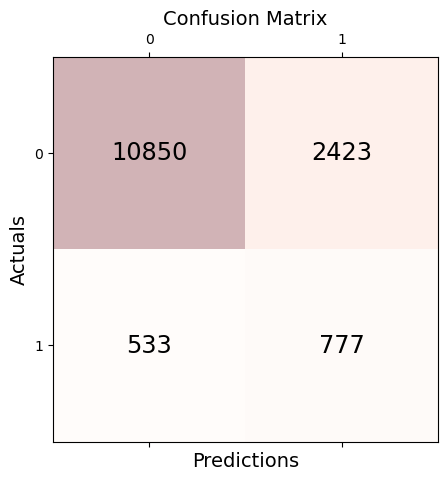

Accuracy: 79.73%
Precision: 24.28%
Recall: 59.31%
Specificity: 81.74%
F1: 34.46%


In [82]:
y_pred =adaboost.predict(X_test)
conf_matrix = metrics.confusion_matrix(Y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(conf_matrix, cmap=plt.cm.Reds, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
plt.xlabel('Predictions', fontsize=14)
plt.ylabel('Actuals', fontsize=14)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

print('Accuracy:', '{:.2%}'.format(metrics.accuracy_score(Y_test, y_pred)))
print('Precision:', '{:.2%}'.format(metrics.precision_score(Y_test, y_pred)))
print('Recall:', '{:.2%}'.format(metrics.recall_score(Y_test, y_pred)))
print('Specificity:', '{:.2%}'.format((conf_matrix[0][0])/(conf_matrix[0][0]+conf_matrix[0][1])))
print('F1:', '{:.2%}'.format(metrics.f1_score(Y_test, y_pred)))

In [83]:
ada = pd.Series({'Model': "Ada BOOST",
                     'AUC Score' : metrics.roc_auc_score(Y_test, y_pred),
                 'Precision Score': metrics.precision_score(Y_test, y_pred),
                 'Recall Score': metrics.recall_score(Y_test, y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, y_pred),
                  'f1-score':metrics.f1_score(Y_test, y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(ada , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828
8,Extra Trees Classifier,0.435939,0.412977,0.899266,0.424147,0.680119
9,Tuned Extra Trees Classifier,0.207440,0.834351,0.698759,0.332269,0.759864


## Meta Estimator

In [84]:
from sklearn.ensemble import BaggingClassifier
from sklearn import tree

meta_estimator = BaggingClassifier(tree.DecisionTreeClassifier(random_state=10))
meta_estimator.fit(X_train_res,Y_train_res)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=10))

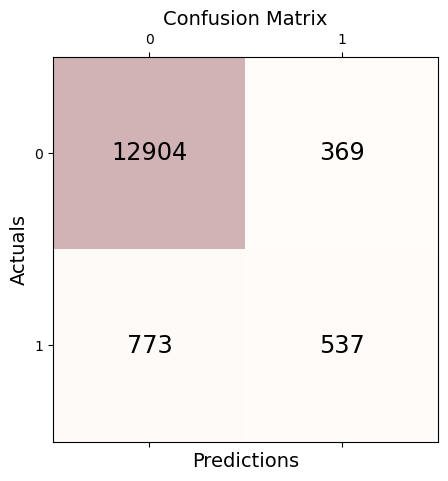

Accuracy: 92.17%
Precision: 59.27%
Recall: 40.99%
Specificity: 97.22%
F1: 48.47%


In [85]:
y_pred =meta_estimator.predict(X_test)
conf_matrix = metrics.confusion_matrix(Y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(conf_matrix, cmap=plt.cm.Reds, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
plt.xlabel('Predictions', fontsize=14)
plt.ylabel('Actuals', fontsize=14)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

print('Accuracy:', '{:.2%}'.format(metrics.accuracy_score(Y_test, y_pred)))
print('Precision:', '{:.2%}'.format(metrics.precision_score(Y_test, y_pred)))
print('Recall:', '{:.2%}'.format(metrics.recall_score(Y_test, y_pred)))
print('Specificity:', '{:.2%}'.format((conf_matrix[0][0])/(conf_matrix[0][0]+conf_matrix[0][1])))
print('F1:', '{:.2%}'.format(metrics.f1_score(Y_test, y_pred)))

In [86]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,y_pred))
 
acc=accuracy_score(Y_test, y_pred)
print("Accuracy of the model: ",acc)

[[12904   369]
 [  773   537]]
Classification report: 
              precision    recall  f1-score   support

           0       0.94      0.97      0.96     13273
           1       0.59      0.41      0.48      1310

    accuracy                           0.92     14583
   macro avg       0.77      0.69      0.72     14583
weighted avg       0.91      0.92      0.92     14583

Accuracy of the model:  0.9216896386203113


In [87]:
meta_est = pd.Series({'Model': "Meta Estimator",
                     'AUC Score' : metrics.roc_auc_score(Y_test, y_pred),
                 'Precision Score': metrics.precision_score(Y_test, y_pred),
                 'Recall Score': metrics.recall_score(Y_test, y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, y_pred),
                  'f1-score':metrics.f1_score(Y_test, y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(meta_est , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828
8,Extra Trees Classifier,0.435939,0.412977,0.899266,0.424147,0.680119
9,Tuned Extra Trees Classifier,0.207440,0.834351,0.698759,0.332269,0.759864


## XG Boost

In [88]:
from xgboost.sklearn import XGBClassifier

xgbm = XGBClassifier(random_state=1,learning_rate=0.01)
xgbm.fit(X_train_res,Y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=1, ...)

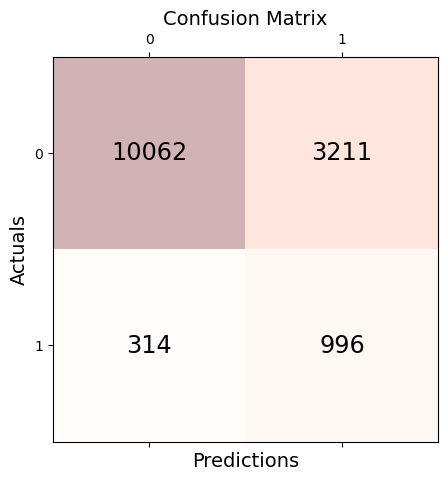

Accuracy: 75.83%
Precision: 23.67%
Recall: 76.03%
Specificity: 75.81%
F1: 36.11%


In [89]:
y_pred =xgbm.predict(X_test)
conf_matrix = metrics.confusion_matrix(Y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(conf_matrix, cmap=plt.cm.Reds, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
plt.xlabel('Predictions', fontsize=14)
plt.ylabel('Actuals', fontsize=14)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

print('Accuracy:', '{:.2%}'.format(metrics.accuracy_score(Y_test, y_pred)))
print('Precision:', '{:.2%}'.format(metrics.precision_score(Y_test, y_pred)))
print('Recall:', '{:.2%}'.format(metrics.recall_score(Y_test, y_pred)))
print('Specificity:', '{:.2%}'.format((conf_matrix[0][0])/(conf_matrix[0][0]+conf_matrix[0][1])))
print('F1:', '{:.2%}'.format(metrics.f1_score(Y_test, y_pred)))

In [90]:
xgbm = pd.Series({'Model': "XG BOOST",
                     'AUC Score' : metrics.roc_auc_score(Y_test, y_pred),
                 'Precision Score': metrics.precision_score(Y_test, y_pred),
                 'Recall Score': metrics.recall_score(Y_test, y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, y_pred),
                  'f1-score':metrics.f1_score(Y_test, y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(xgbm , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828
8,Extra Trees Classifier,0.435939,0.412977,0.899266,0.424147,0.680119
9,Tuned Extra Trees Classifier,0.207440,0.834351,0.698759,0.332269,0.759864


In [91]:
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828
8,Extra Trees Classifier,0.435939,0.412977,0.899266,0.424147,0.680119
9,Tuned Extra Trees Classifier,0.207440,0.834351,0.698759,0.332269,0.759864


## SGD

In [92]:
from sklearn.linear_model import SGDClassifier
SGD = SGDClassifier(loss = 'log', random_state = 10)

# The 'log' loss gives logistic regression, a probabilistic  
# fit the model on scaled training data
logreg_with_SGD = SGD.fit(X_train_res, Y_train_res)
y_pred_prob = logreg_with_SGD.predict_proba(X_test)[:,1]
y_pred_prob
y_pred = logreg_with_SGD.predict(X_test)
y_pred
#plot_confusion_matrix(logreg_with_SGD)

array([0, 0, 0, ..., 1, 1, 0])

In [93]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,y_pred)
print(cfm)
 
print("Classification report: ")
 
print(classification_report(Y_test,y_pred))
 
acc=accuracy_score(Y_test, y_pred)
print("Accuracy of the model: ",acc)

[[9644 3629]
 [ 396  914]]
Classification report: 
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     13273
           1       0.20      0.70      0.31      1310

    accuracy                           0.72     14583
   macro avg       0.58      0.71      0.57     14583
weighted avg       0.89      0.72      0.78     14583

Accuracy of the model:  0.7239936912843722


In [94]:
sgd = pd.Series({'Model': "Stocastic Gradient Descent",
                     'AUC Score' : metrics.roc_auc_score(Y_test, y_pred),
                 'Precision Score': metrics.precision_score(Y_test, y_pred),
                 'Recall Score': metrics.recall_score(Y_test, y_pred),
                 'Accuracy Score': metrics.accuracy_score(Y_test, y_pred),
                  'f1-score':metrics.f1_score(Y_test, y_pred)})



# appending our result table
result_tabulation = result_tabulation.append(sgd , ignore_index = True)

# view the result table
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828
8,Extra Trees Classifier,0.435939,0.412977,0.899266,0.424147,0.680119
9,Tuned Extra Trees Classifier,0.207440,0.834351,0.698759,0.332269,0.759864


In [95]:
result_tabulation

,Model,Precision Score,Recall Score,Accuracy Score,f1-score,AUC Score
0,Decision Tree,0.403711,0.481679,0.889529,0.439262,0.705731
1,Tuned Decision Tree,0.210236,0.815267,0.708290,0.334272,0.756500
2,Logistic Regression,0.201505,0.715267,0.719811,0.314430,0.717763
3,Tuned Logistic Regression,0.195156,0.750382,0.699582,0.309753,0.722475
4,K-Nearest Neighbours,0.247997,0.567176,0.806624,0.345100,0.698716
5,Naive Bayes,0.219429,0.539695,0.786189,0.312004,0.675106
6,Random Forest,0.598237,0.362595,0.920867,0.451521,0.669281
7,Tuned Random Forest,0.253831,0.695420,0.789001,0.371913,0.746828
8,Extra Trees Classifier,0.435939,0.412977,0.899266,0.424147,0.680119
9,Tuned Extra Trees Classifier,0.207440,0.834351,0.698759,0.332269,0.759864


* From the above results we can see that Random Forest and Meta Estimator works best based on accuracy score but we can apply Tuned Extra Trees Classifier when Recall score is more important.

In [96]:
test_pred=meta_estimator.predict(test)
test_pred

array([0, 0, 0, ..., 0, 0, 1])

In [97]:
test_df["Pred"]=test_pred
test_df["Pred"]=test_df["Pred"].replace({0:"not_promoted",1:"is_promoted"})
test_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,Pred
0,8724,8,18,0,1,2,1,NaN,1,1,0,77,not_promoted
1,74430,2,28,0,0,0,1,3.0,5,0,0,51,not_promoted
2,72255,7,4,0,1,0,1,1.0,4,0,0,47,not_promoted
3,38562,5,11,0,0,0,3,2.0,9,0,0,65,not_promoted
4,64486,1,21,0,1,2,1,4.0,7,0,0,61,not_promoted


In [98]:
test_df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,Pred
0,8724,8,18,0,1,2,1,NaN,1,1,0,77,not_promoted
1,74430,2,28,0,0,0,1,3.0,5,0,0,51,not_promoted
2,72255,7,4,0,1,0,1,1.0,4,0,0,47,not_promoted
3,38562,5,11,0,0,0,3,2.0,9,0,0,65,not_promoted
4,64486,1,21,0,1,2,1,4.0,7,0,0,61,not_promoted
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,3,11,1,1,2,1,3.0,1,0,0,61,not_promoted
23486,25600,8,17,0,1,2,1,3.0,7,0,0,74,not_promoted
23487,45409,2,7,0,0,2,1,4.0,4,0,0,50,not_promoted
23488,1186,5,24,0,1,2,3,NaN,1,0,0,70,not_promoted


Number of employees not promoted :  20789
Number of employees promoted :  2701


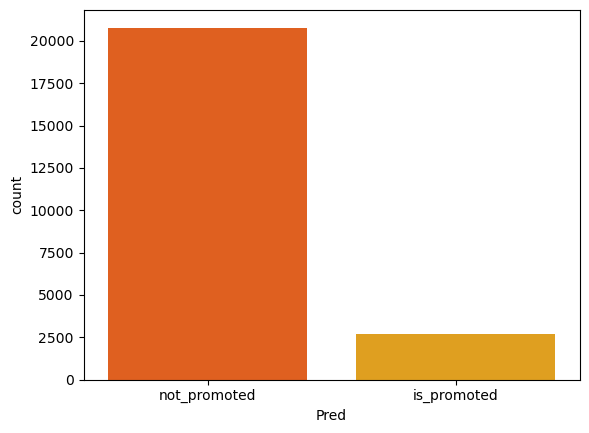

In [99]:
sns.countplot(x=test_df['Pred'],data=test_df,palette="autumn")
S, N = test_df['Pred'].value_counts()
print('Number of employees not promoted : ',S)
print('Number of employees promoted : ',N)

* The above predictions are done on the basis of meta_estimator as it has good precision as well as good accuracy score.